In [1]:
import pandas as pd
import numpy as np

from prophet import Prophet

import matplotlib.pyplot as plt

from pathlib import Path

import joblib

In [2]:
ROOT_DIR = Path("..")

rossmann = pd.read_csv(
    ROOT_DIR /
    "data" /
    "processed" /
    "rossmann_clean.csv",
    low_memory=False
)

rossmann["Date"] = pd.to_datetime(
    rossmann["Date"]
)

In [3]:
daily_sales = (
    rossmann
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.columns = [
    "ds",
    "y"
]

In [4]:
daily_sales["y"] = np.log1p(
    daily_sales["y"]
)

In [5]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(daily_sales)

16:09:50 - cmdstanpy - INFO - Chain [1] start processing


16:09:50 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
future = model.make_future_dataframe(
    periods=90
)

forecast = model.predict(
    future
)

In [7]:
forecast["predicted_sales"] = np.expm1(
    forecast["yhat"]
)

forecast["lower_sales"] = np.expm1(
    forecast["yhat_lower"]
)

forecast["upper_sales"] = np.expm1(
    forecast["yhat_upper"]
)

In [8]:
forecast[
[
    "ds",
    "predicted_sales",
    "lower_sales",
    "upper_sales"
]
].tail()

,ds,predicted_sales,lower_sales,upper_sales
1027,2015-10-25,2.589395e+05,1.258316e+05,5.714724e+05
1028,2015-10-26,8.694295e+06,3.994248e+06,1.807047e+07
1029,2015-10-27,8.638915e+06,3.997078e+06,1.785444e+07
1030,2015-10-28,7.812471e+06,3.997152e+06,1.599823e+07
1031,2015-10-29,6.838055e+06,3.403446e+06,1.530615e+07


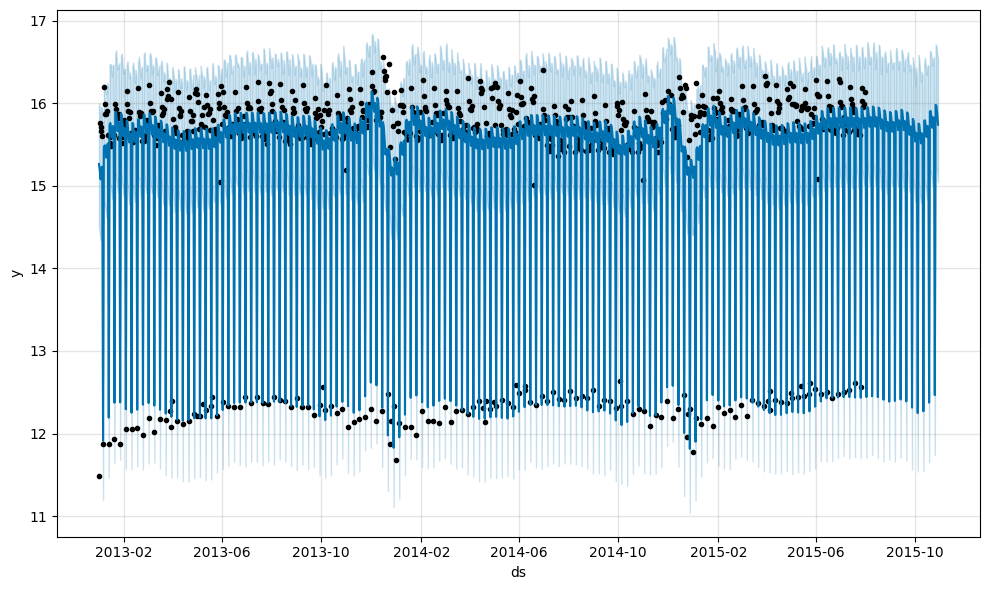

In [9]:
fig = model.plot(
    forecast
)
plt.show()

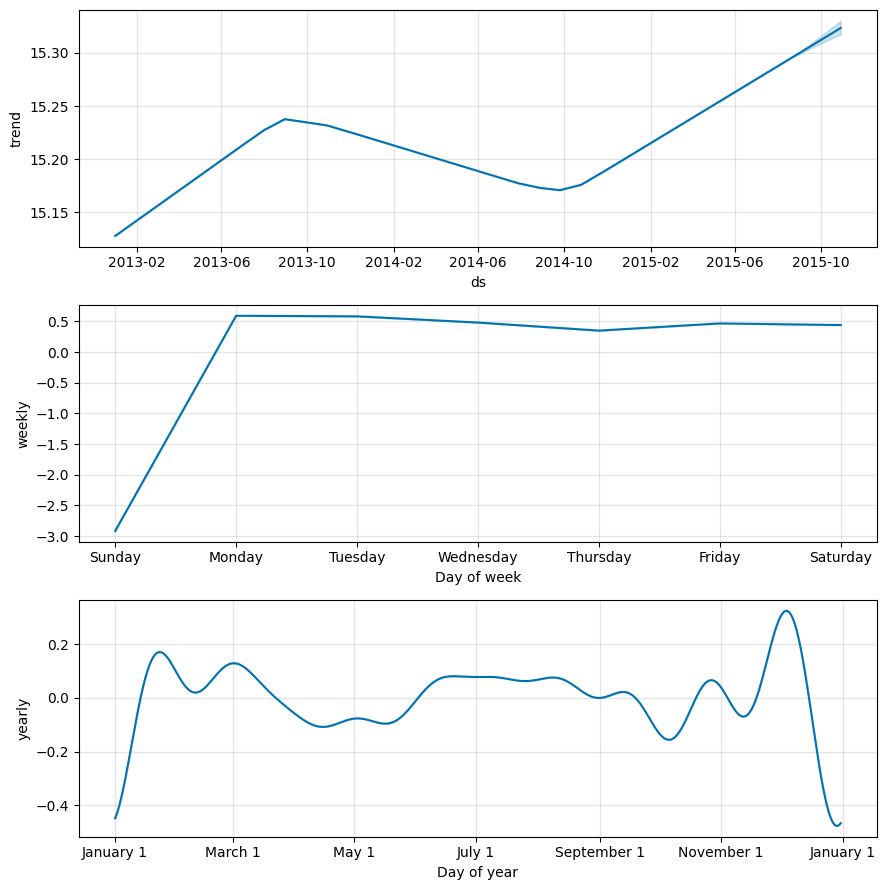

In [10]:
fig2 = model.plot_components(
    forecast
)
plt.show()

In [11]:
MODEL_DIR = (
    ROOT_DIR /
    "models" /
    "prophet"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    model,
    MODEL_DIR /
    "prophet_model.pkl"
)

['..\\models\\prophet\\prophet_model.pkl']

In [12]:
forecast.to_csv(
    MODEL_DIR /
    "forecast.csv",
    index=False
)

In [13]:
print("Model Saved Successfully")
print("Forecast Saved Successfully")

Model Saved Successfully
Forecast Saved Successfully


XGBoost Revenue Prediction

In [14]:
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

import joblib

In [15]:
ROOT_DIR = Path("..")

rossmann = pd.read_csv(
    ROOT_DIR /
    "data" /
    "processed" /
    "rossmann_clean.csv",
    low_memory=False
)

In [16]:
features = [
    "DayOfWeek",
    "Customers",
    "Promo",
    "SchoolHoliday",
    "CompetitionDistance",
    "Promo2",
    "Year",
    "Month",
    "Week",
    "Quarter",
    "IsWeekend",
    "CompetitionAge",
    "PromoActive",
    "IsHoliday",
    "IsSchoolHoliday",
    "SalesPerCustomer",
    "MonthStart",
    "MonthEnd"
]

In [17]:
X = rossmann[features]

y = rossmann["Sales"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [20]:
predictions = xgb_model.predict(
    X_test
)

In [21]:
mae = mean_absolute_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

print(f"MAE : {mae:,.2f}")
print(f"R²  : {r2:.4f}")

MAE : 35.41
R²  : 0.9989


In [22]:
importance = pd.DataFrame(
{
    "Feature": features,
    "Importance": xgb_model.feature_importances_
}
)

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
1,Customers,0.816619
15,SalesPerCustomer,0.117681
2,Promo,0.017624
12,PromoActive,0.016346
13,IsHoliday,0.006929
5,Promo2,0.005081
4,CompetitionDistance,0.004602
0,DayOfWeek,0.003396
11,CompetitionAge,0.002918
8,Week,0.001805


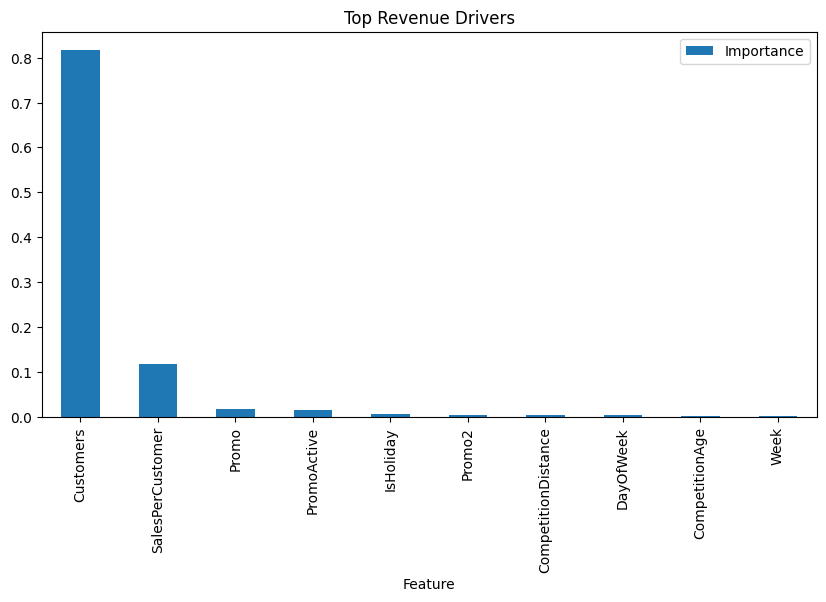

In [23]:
importance.head(10).plot(
    x="Feature",
    y="Importance",
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Top Revenue Drivers"
)

plt.show()

In [24]:
MODEL_DIR = (
    ROOT_DIR /
    "models" /
    "xgboost"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [25]:
joblib.dump(
    xgb_model,
    MODEL_DIR /
    "xgboost_model.pkl"
)

['..\\models\\xgboost\\xgboost_model.pkl']

In [26]:
importance.to_csv(
    MODEL_DIR /
    "feature_importance.csv",
    index=False
)

In [27]:
print(f"MAE : {mae:,.2f}")
print(f"R²  : {r2:.4f}")

MAE : 35.41
R²  : 0.9989


In [28]:
importance.head(10)

,Feature,Importance
1,Customers,0.816619
15,SalesPerCustomer,0.117681
2,Promo,0.017624
12,PromoActive,0.016346
13,IsHoliday,0.006929
5,Promo2,0.005081
4,CompetitionDistance,0.004602
0,DayOfWeek,0.003396
11,CompetitionAge,0.002918
8,Week,0.001805


In [29]:
superstore = pd.read_csv(
    ROOT_DIR /
    "data" /
    "processed" /
    "superstore_clean.csv",
    encoding="latin1"
)

superstore["Order Date"] = pd.to_datetime(
    superstore["Order Date"]
)

In [30]:
customer_features = (
    superstore
    .groupby("Customer ID")
    .agg({
        "Sales": "sum",
        "Profit": "sum",
        "Quantity": "sum",
        "Order ID": "nunique"
    })
    .reset_index()
)

In [31]:
customer_features.columns = [
    "customer_id",
    "total_sales",
    "total_profit",
    "total_quantity",
    "total_orders"
]

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    customer_features[
        [
            "total_sales",
            "total_profit",
            "total_quantity",
            "total_orders"
        ]
    ]
)

In [33]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_features["segment"] = (
    kmeans.fit_predict(
        scaled_features
    )
)

In [34]:
segment_summary = (
    customer_features
    .groupby("segment")
    .agg({
        "total_sales":"mean",
        "total_profit":"mean",
        "total_orders":"mean"
    })
    .round(2)
)

segment_summary

,total_sales,total_profit,total_orders
segment,,,
0,2874.51,328.13,7.02
1,9951.14,2502.72,7.80
2,4583.98,421.79,9.91
3,1238.83,56.37,3.98


In [35]:
customer_features["segment"]\
.value_counts()

segment
0    331
3    303
2    114
1     45
Name: count, dtype: int64

In [36]:
MODEL_DIR = (
    ROOT_DIR /
    "models" /
    "kmeans"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    kmeans,
    MODEL_DIR /
    "kmeans_model.pkl"
)

['..\\models\\kmeans\\kmeans_model.pkl']

In [37]:
customer_features.to_csv(
    MODEL_DIR /
    "customer_segments.csv",
    index=False
)